1.Average, median, and mode of PurchaseAmount

In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("customer_behavior.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


In [5]:
average = df.PurchaseAmount.mean()
median = df.PurchaseAmount.median()
mode = df.PurchaseAmount.mode()

print(average)
print(median)
print(mode)


1003.9506701030928
998.0799999999999
0    0.0
Name: PurchaseAmount, dtype: float64


2.Outliers in the PurchaseAmount data

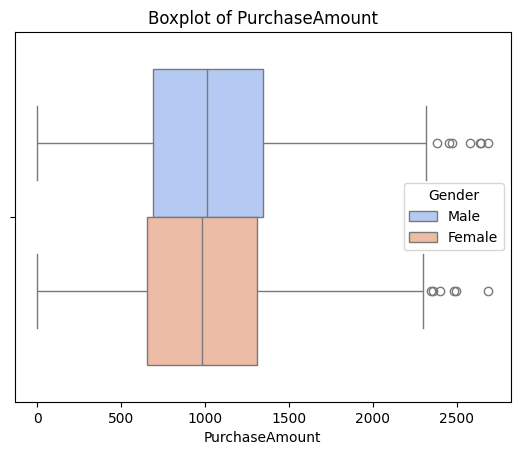

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df.PurchaseAmount,palette="coolwarm",hue=df.Gender)
plt.title("Boxplot of PurchaseAmount")
plt.show()

There are outliers in the purchase amount data

3.Skewness or kurtosis in the PurchaseAmount distribution

In [10]:
print(df.PurchaseAmount.skew())
print(df.PurchaseAmount.kurt())

0.10609189374631554
-0.2615105545319705


PurchaseAmount has a skewness of 0.106, indicating that the distribution is approximately symmetric with a very slight right skew. The kurtosis is -0.262 indicating a slightly flatter distribution with lighter tails Overall, the distribution is reasonably close to symmetric and does not show strong skewness.

4.Significant difference in spending between male and female
customers Ho = No significant difference between male and female customers H1 = Significant difference between male and female customers

In [13]:
from scipy.stats import ttest_ind

male = df[df.Gender == "Male"].PurchaseAmount.dropna()
female = df[df.Gender == "Female"].PurchaseAmount.dropna()
t_stat, p_val = ttest_ind(male, female)

print(t_stat)
print(p_val)
alpha =0.05
if p_val < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

2.234885143428604
0.025471167149519254
Reject the null hypothesis


5.Relationship between ProductCategory and customer churn H0: No relationship between Product Category and Customer Churn H1: Relationship between Product Category and Customer Churn

In [17]:
from scipy.stats import chi2_contingency

from scipy.stats import chi2_contingency
import pandas as pd

table = pd.crosstab(df["ProductCategory"], df["Churn"])

chi2, p_val, _, _ = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p_val)

alpha = 0.05

if p_val < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

Chi-square: 0.3960436652673918
p-value: 0.8203519424988512
Fail to reject the null hypothesis


6.PurchaseAmount vary significantly across different regions Ho:PurchaseAmount differs significantly across regions H1: Purchase amount does not differ across regions

In [23]:
from scipy.stats import f_oneway
df_new = df.dropna(subset=["PurchaseAmount"])
groups = [
    group["PurchaseAmount"].values
    for name, group in df_new.groupby("Region")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")


F-statistic: 0.38966786354806704
p-value: 0.760452802731563
Fail to reject the null hypothesis


7.Email campaign (A or B) performed better in terms of average
PurchaseAmount  

In [24]:
campaign_avg = df.groupby("CampaignGroup")["PurchaseAmount"].mean()

print(campaign_avg)

CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64


Team A performed better

8.PurchaseAmount follows a normal distribution

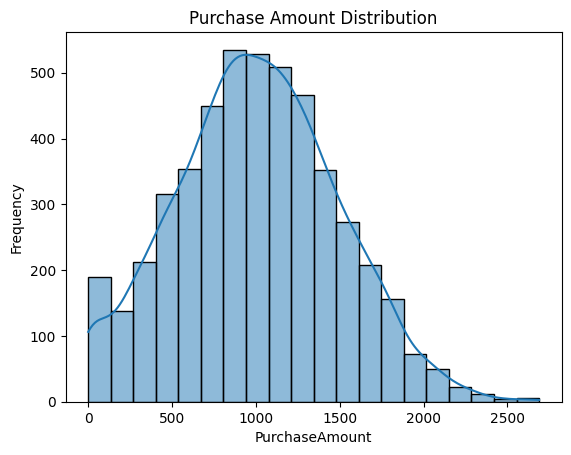

In [31]:
sns.histplot(df["PurchaseAmount"].dropna(), bins=20,kde=True)
plt.title("Purchase Amount Distribution")
plt.xlabel("PurchaseAmount")
plt.ylabel("Frequency")
plt.show()

This has a normal distribution because kde curve is bell shaped

9.Central Limit Theorem:
Distribution of sample means tends to become approximately normal, even if the original PurchaseAmount distribution is not normal for sufficiently large random samples

10.95% confidence interval for the average PurchaseAmount

In [33]:
import scipy.stats as stats
import numpy as np

data = df["PurchaseAmount"].dropna()

n = len(data)
mean = data.mean()
std = data.std()

confidence = 0.95

standard_error = std / np.sqrt(n)

t_critical = stats.t.ppf(0.975, df=n-1)

margin_error = t_critical * standard_error

lower = mean - margin_error
upper = mean + margin_error

print("Mean:", mean)
print("95% Confidence Interval:", lower, "to", upper)

Mean: 1003.9506701030928
95% Confidence Interval: 990.3789594609216 to 1017.522380745264
